# MLP

I0000 00:00:1781378096.523179   13214 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


genre: pop


/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=690
  warnings.warn(
/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=345
  warnings.warn(


genre: rock
genre: classical


/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/.venv/lib/python3.12/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


genre: blues
genre: country
genre: disco
genre: metal
genre: jazz


/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/mlp.py:92: UserWarning: PySoundFile failed. Trying audioread instead.
  sig, sr = librosa.load(fn, mono=True, duration=28)  # Load 28 seconds of the file
/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/.venv/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


ERROR jazz.00054.wav: 


/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=690
  warnings.warn(
/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=345
  warnings.warn(
/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/.venv/lib/python3.12/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


genre: reggae
genre: hiphop
Data size: (48951, 82)
Data labels size: (48951,)
Data size: (48951, 82)
Data_labels size: (48951,)
Train: (29370,)
Test: (9791,)
Val: (9790,)


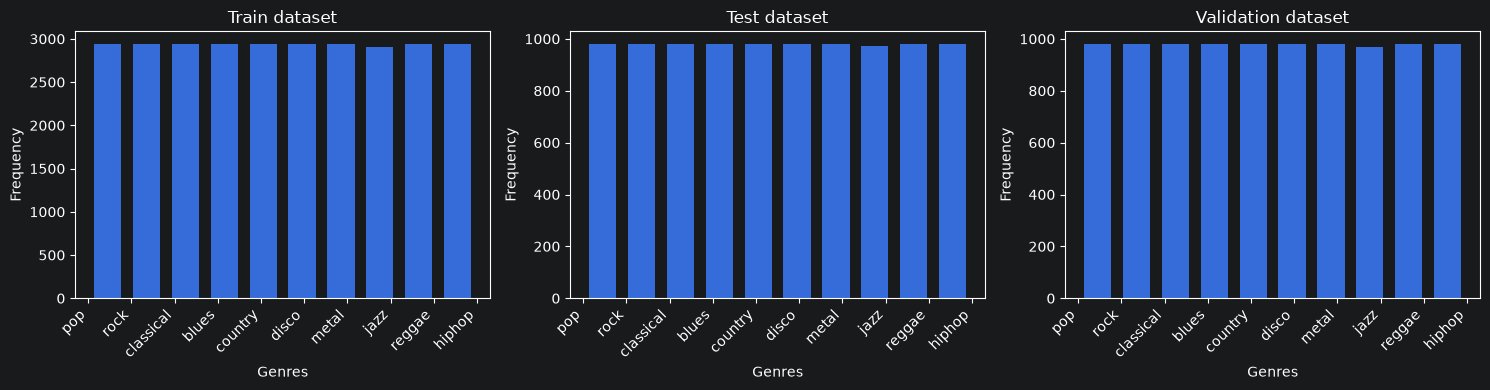

In [1]:
import mlp

from importlib import reload
from mlp import *

reload(mlp)

DATASET_NAME = "mlp_dataset.h5"

genres = np.array('pop rock classical blues country disco metal jazz reggae hiphop'.split())
n_genres = len(genres) # 10 genres
n_genres_files = 100   # Files per genre, 1000 total
n_mfcc_coef = 10       # Experiment with no. of coeffs.
n_parts_sig_range = [7, 14, 28]  # 4s, 2s, 1s parts of 28s signal

generate_dataset(DATASET_NAME, genres, n_mfcc_coef, n_parts_sig_range)
data, data_labels = load_dataset(DATASET_NAME)
X_train, X_val, X_test, y_train, y_val, y_test = normalize_and_split_dataset(data, data_labels)
plot_dataset_labels(y_train, y_test, y_val, genres)

W0000 00:00:1781386010.646326   13214 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,050 (246.29 KB)

 Trainable params: 63,050 (246.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.2487 - sparse_categorical_accuracy: 0.5682 - val_loss: 0.8315 - val_sparse_categorical_accuracy: 0.7183
Epoch 2/150
918/918 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9070 - sparse_categorical_accuracy: 0.6909 - val_loss: 0.7022 - val_sparse_categorical_accuracy: 0.7608
Epoch 3/150
918/918 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7880 - sparse_categorical_accuracy: 0.7305 - val_loss: 0.6117 - val_sparse_categorical_accuracy: 0.7897
Epoch 4/150
918/918 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7149 - sparse_categorical_accuracy: 0.7557 - val_loss: 0.5777 - val_sparse_categorical_accuracy: 0.8012
Epoch 5/150
918/918 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6685 - sparse_categorical_accuracy: 0.7709 - val_loss: 0.5469 - val_sparse_categorical_accuracy: 0.8143
Epoch 6/150
918/918 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6278 - sparse_categorical_accuracy: 0.7847 - val_loss: 0.5085 - val_sparse_categorical_accuracy: 0.828

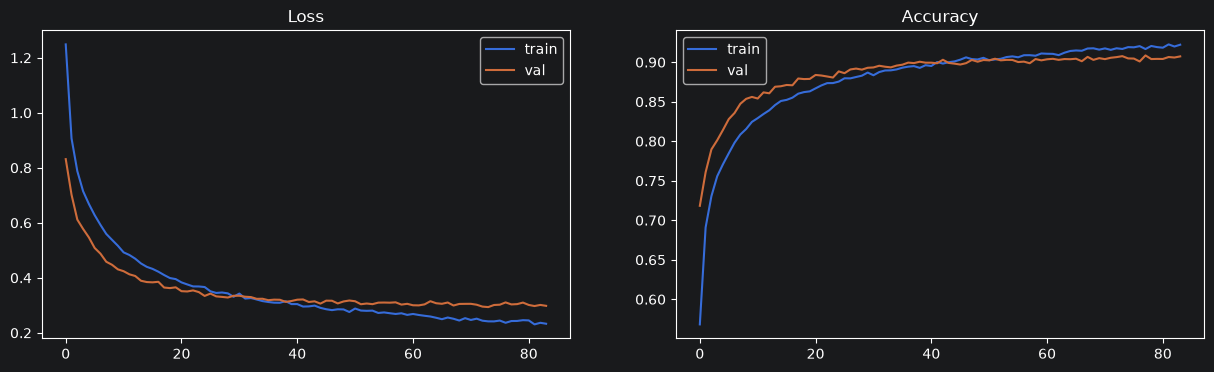

In [2]:
model, history = train_model(X_train, y_train, X_val, y_val, n_genres)
plot_history(history)

Acc train NN: 0.988
Acc test NN: 0.906
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step


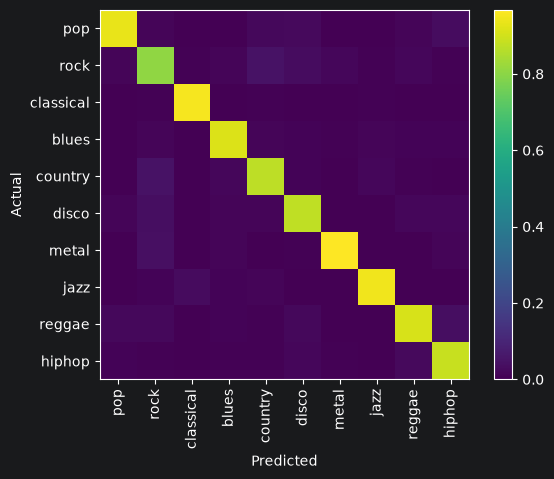

In [3]:
evaluate_model(model, X_test, y_test, X_train, y_train, genres)